# Customer Purchase Analysis

In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#Load the Datasets
transcation = pd.read_excel("C:\\Users\\Suraj\\Documents\\Data analysis\\Customer Purchase Analysis\\QVI_transaction_data.xlsx")
customer = pd.read_csv("C:\\Users\\Suraj\\Documents\\Data analysis\\Customer Purchase Analysis\\QVI_purchase_behaviour.csv")

## Understanding the Datasets

In [4]:
transcation.head()
customer.head()

# Check the shape
transcation.shape
customer.shape

# check the columns 
transcation.columns
customer.columns

# check of datatyoe
transcation.info()
customer.info()

# Analysis the data
transcation.describe()
customer.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   DATE            264836 non-null  int64  
 1   STORE_NBR       264836 non-null  int64  
 2   LYLTY_CARD_NBR  264836 non-null  int64  
 3   TXN_ID          264836 non-null  int64  
 4   PROD_NBR        264836 non-null  int64  
 5   PROD_NAME       264836 non-null  object 
 6   PROD_QTY        264836 non-null  int64  
 7   TOT_SALES       264836 non-null  float64
dtypes: float64(1), int64(6), object(1)
memory usage: 16.2+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72637 entries, 0 to 72636
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   LYLTY_CARD_NBR    72637 non-null  int64 
 1   LIFESTAGE         72637 non-null  object
 2   PREMIUM_CUSTOMER  72637 non-null  object
dtypes: int64(1), object(2)
m

,LYLTY_CARD_NBR
count,7.263700e+04
mean,1.361859e+05
std,8.989293e+04
min,1.000000e+03
25%,6.620200e+04
50%,1.340400e+05
75%,2.033750e+05
max,2.373711e+06


# Data Cleaning

In [5]:
# Check the null values
transcation.isnull().sum()
customer.isnull().sum()

#Check the duplicate values
transcation.duplicated().sum()
customer.duplicated().sum()

np.int64(0)

In [6]:
# identify the Outliers
transcation["PROD_QTY"].describe()

transcation[transcation["PROD_QTY"] == 200]
customer[customer["LYLTY_CARD_NBR"] == 226000]

# mark the outlier 
outlier = transcation[
    transcation["PROD_QTY"] == 200
]

# Remove the outlier
transcation = transcation[transcation["LYLTY_CARD_NBR"] != 226000]
transcation[transcation["LYLTY_CARD_NBR"] == 226000]



,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES


# Feature Engineering

In [7]:
# Extract pack size
transcation["Pack_Size"] = (
    transcation["PROD_NAME"].str.extract(r'(\d+)')
)

#Extract Brand name
transcation["BRAND"] = (
    transcation["PROD_NAME"]
    .str.split()
    .str[0]
)

transcation["Pack_Size"]
transcation["BRAND"]

0          Natural
1              CCs
2           Smiths
3           Smiths
4           Kettle
            ...   
264831      Kettle
264832    Tostitos
264833     Doritos
264834     Doritos
264835    Tostitos
Name: BRAND, Length: 264834, dtype: object

# Combine the tables

In [8]:
data = pd.merge(
    transcation,
    customer,
    on = "LYLTY_CARD_NBR",
    how = "left"
)

data.shape
data.head()

# Change the date format
data["DATE"] = pd.to_datetime(
    data["DATE"],
    origin="1899-12-30",
    unit="D"
)

data

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,Pack_Size,BRAND,LIFESTAGE,PREMIUM_CUSTOMER
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175,Natural,YOUNG SINGLES/COUPLES,Premium
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,175,CCs,MIDAGE SINGLES/COUPLES,Budget
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,170,Smiths,MIDAGE SINGLES/COUPLES,Budget
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,175,Smiths,MIDAGE SINGLES/COUPLES,Budget
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,150,Kettle,MIDAGE SINGLES/COUPLES,Budget
...,...,...,...,...,...,...,...,...,...,...,...,...
264829,2019-03-09,272,272319,270088,89,Kettle Sweet Chilli And Sour Cream 175g,2,10.8,175,Kettle,YOUNG SINGLES/COUPLES,Premium
264830,2018-08-13,272,272358,270154,74,Tostitos Splash Of Lime 175g,1,4.4,175,Tostitos,YOUNG SINGLES/COUPLES,Premium
264831,2018-11-06,272,272379,270187,51,Doritos Mexicana 170g,2,8.8,170,Doritos,YOUNG SINGLES/COUPLES,Premium
264832,2018-12-27,272,272379,270188,42,Doritos Corn Chip Mexican Jalapeno 150g,2,7.8,150,Doritos,YOUNG SINGLES/COUPLES,Premium


# Exploratory Data Analysis (EDA)

In [9]:
#Total sales
data["TOT_SALES"].sum()

#Monthly sales
data.groupby("DATE")["TOT_SALES"].sum()


DATE
2018-07-01    5372.2
2018-07-02    5315.4
2018-07-03    5321.8
2018-07-04    5309.9
2018-07-05    5080.9
               ...  
2019-06-26    5305.0
2019-06-27    5202.8
2019-06-28    5299.6
2019-06-29    5497.6
2019-06-30    5423.4
Name: TOT_SALES, Length: 364, dtype: float64

# Customer Segmentation Analysis

In [10]:
# Sales by lifestage
sales_life= (data.groupby("LIFESTAGE")["TOT_SALES"].sum().sort_values(ascending = False))
sales_life

# Sales by Premium Segment
sales_premium= (data.groupby("PREMIUM_CUSTOMER")["TOT_SALES"].sum().sort_values(ascending = False))
sales_premium



PREMIUM_CUSTOMER
Mainstream    750744.50
Budget        676211.55
Premium       506158.95
Name: TOT_SALES, dtype: float64

# Customer Purchasing Behaviour

In [11]:
# Average Spend
avg_spend = data.groupby(["LIFESTAGE","PREMIUM_CUSTOMER"])["TOT_SALES"].mean()
avg_spend

# Transactions Per Customer
trans_per_cust = data.groupby(["LIFESTAGE","PREMIUM_CUSTOMER"])["TXN_ID"].count()
trans_per_cust

#Average Quantity Purchased
avg_qty = data.groupby(
    ["LIFESTAGE","PREMIUM_CUSTOMER"]
)["PROD_QTY"].mean()

avg_qty

LIFESTAGE               PREMIUM_CUSTOMER
MIDAGE SINGLES/COUPLES  Budget              1.891633
                        Mainstream          1.911656
                        Premium             1.889727
NEW FAMILIES            Budget              1.853910
                        Mainstream          1.857634
                        Premium             1.860919
OLDER FAMILIES          Budget              1.945812
                        Mainstream          1.948610
                        Premium             1.945576
OLDER SINGLES/COUPLES   Budget              1.913403
                        Mainstream          1.910525
                        Premium             1.914273
RETIREES                Budget              1.892244
                        Mainstream          1.887543
                        Premium             1.900122
YOUNG FAMILIES          Budget              1.940749
                        Mainstream          1.940342
                        Premium             1.937732
YOUNG

# Product Preference Analysis

In [12]:
# Top Brand
brand_sales = (
    data.groupby("BRAND")["TOT_SALES"]
    .sum().sort_values(ascending=False)
)
print(brand_sales)

# Top pack size
top_size= (data.groupby("Pack_Size")["TOT_SALES"]
    .sum().sort_values(ascending=False)
)
print(top_size)


BRAND
Kettle        390239.8
Smiths        210076.8
Doritos       201538.9
Pringles      177655.5
Old            90785.1
Thins          88852.5
Twisties       81522.1
Tostitos       79789.6
Infuzions      76247.6
Cobs           70569.8
RRD            64954.5
Tyrrells       51647.4
Grain          43048.8
Cheezels       40029.9
Dorito         39052.0
WW             35889.5
Natural        34272.0
Red            30091.5
Infzns         22800.0
CCs            18078.9
Cheetos        16884.5
Smith          14583.4
Woolworths     13454.1
GrnWves         8568.4
NCC             8046.0
French          7929.0
Burger          6831.0
Snbts           5076.2
Sunbites        4600.2
Name: TOT_SALES, dtype: float64
Pack_Size
175    485437.4
150    304288.5
134    177655.5
110    162765.4
170    146673.0
330    136794.3
300    113330.6
165    101360.6
380     75419.6
270     55425.4
210     43048.8
250     26096.7
135     26090.4
200     16007.5
190     14412.9
160     10647.6
90       9676.4
180      8568

# Data Visualization

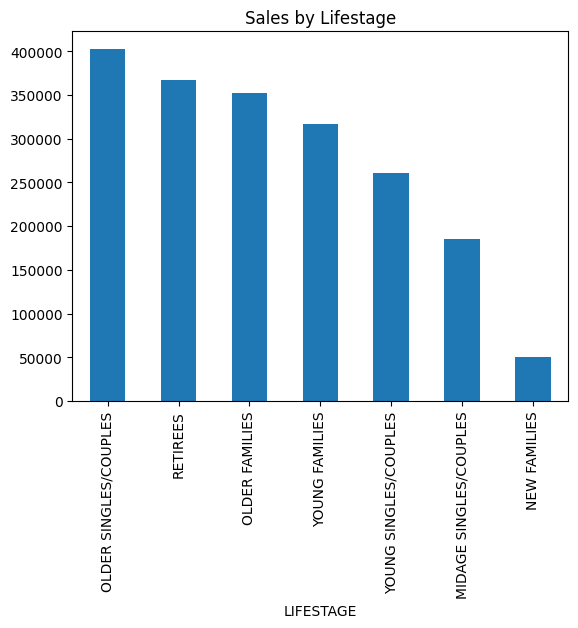

In [13]:
sales_life.plot(kind="bar")
plt.title("Sales by Lifestage")
plt.savefig("Sales.png", dpi=300, bbox_inches="tight")
plt.show()

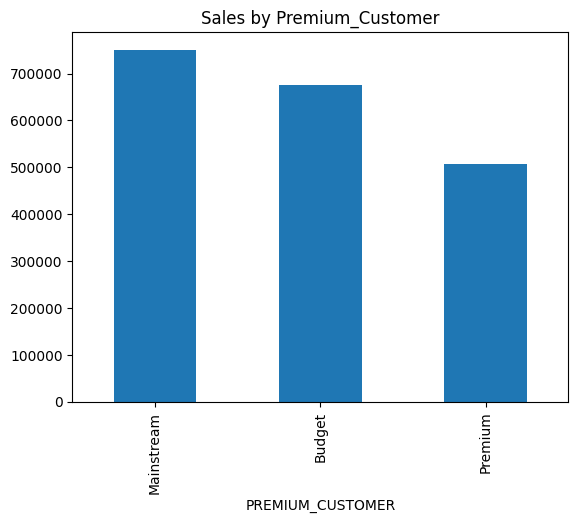

In [21]:
sales_premium.plot(kind="bar")
plt.title("Sales by Premium_Customer")
plt.savefig("PremiumnCustomer.png", dpi=300, bbox_inches="tight")
plt.show()

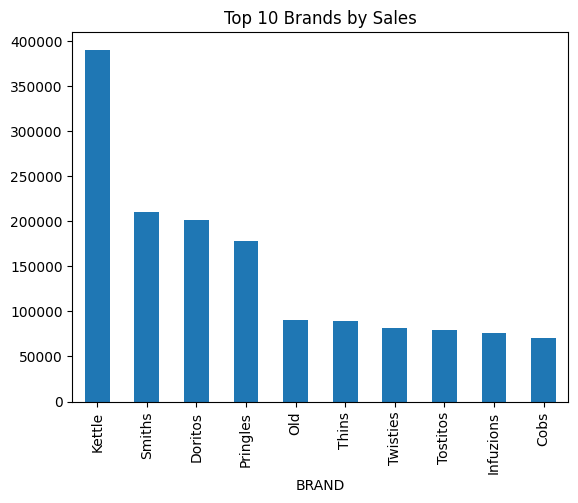

In [16]:
brand_sales = data.groupby("BRAND")["TOT_SALES"].sum().sort_values(ascending=False)

brand_sales.head(10).plot(kind="bar")
plt.title("Top 10 Brands by Sales")
plt.savefig("Top10.png", dpi=300, bbox_inches="tight")
plt.show()

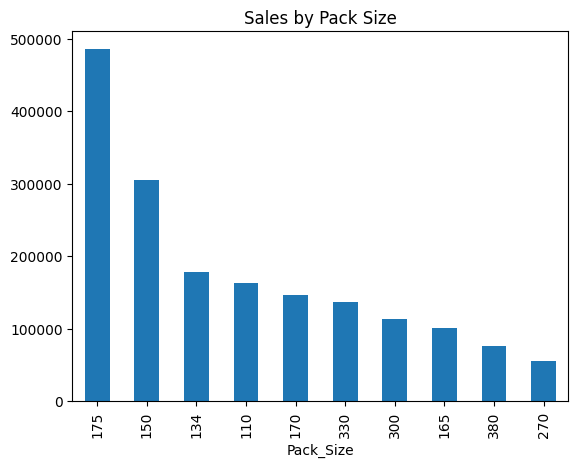

In [18]:
pack_sales = data.groupby("Pack_Size")["TOT_SALES"].sum().sort_values(ascending=False)

pack_sales.head(10).plot(kind="bar")
plt.title("Sales by Pack Size")
plt.savefig("Top_Size.png", dpi=300, bbox_inches="tight")
plt.show()

# Bussines Insight


1. Mainstream customers generated the highest total revenue ($750,744.50), making them the most valuable customer segment in terms of overall sales contribution.

2. Premium Retirees recorded the highest average spend per transaction ($7.46), indicating a stronger willingness to purchase higher-value chip products compared to other customer groups.

3. Kettle was the top-performing brand, generating $390,239.80 in sales. This suggests strong customer preference and brand loyalty toward Kettle products.

4. The 175g pack size was the most popular, contributing $485,437.40 in sales. Customers appear to favor medium-to-large pack sizes, making them a key driver of category performance.

5. Sales performance is primarily driven by Mainstream customers, strong demand for Kettle products, and the popularity of 175g pack sizes across customer segments.

##  Recommendations

- Focus marketing campaigns and promotions on Mainstream customers to maximize revenue growth.
- Maintain strong inventory levels and shelf visibility for Kettle products.
- Prioritize 175g pack sizes in promotional and merchandising strategies.
- Develop targeted premium offerings for Retirees, who demonstrate the highest average spending behavior.

In [66]:
# save the dataset into csv
transcation.to_csv("cleaned_transactions.csv", index=False)
customer.to_csv("cleaned_customers.csv", index=False)
data.to_csv("merged_data.csv", index=False)

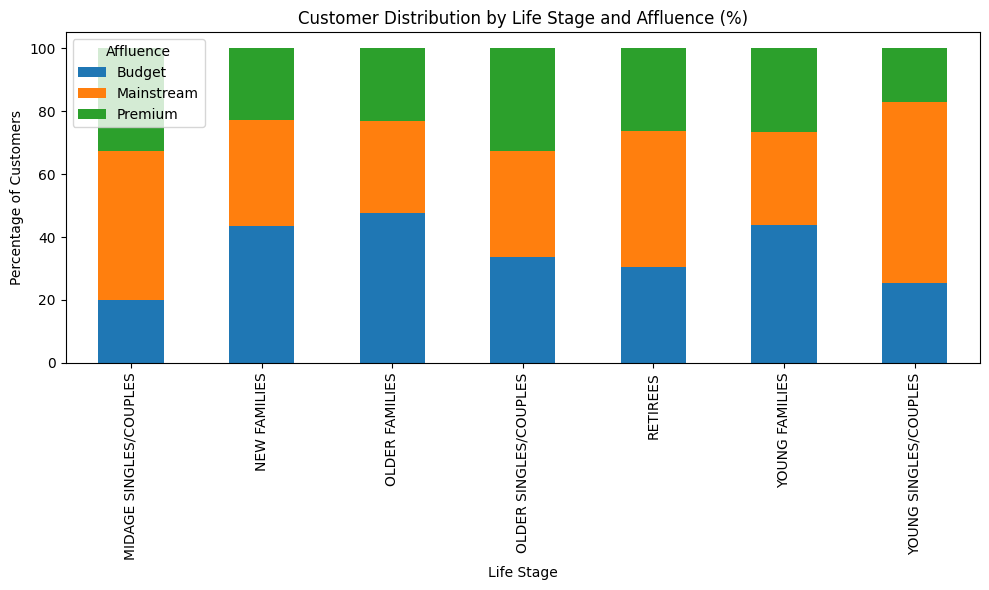

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

customer_prop = pd.crosstab(
    data["LIFESTAGE"],
    data["PREMIUM_CUSTOMER"],
    normalize="index"
) * 100

customer_prop.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6)
)

plt.title(
    "Customer Distribution by Life Stage and Affluence (%)"
)
plt.ylabel("Percentage of Customers")
plt.xlabel("Life Stage")
plt.legend(title="Affluence")
plt.tight_layout()

# Save chart
plt.savefig(
    "customer_distribution_percentage.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()